# Demo 1: Data Extraction, Cleaning, Preprocessing, and Quality Assessment

## 1. Data Collection
### 1.1 Identify raw data sources

**Dataset:** RetailRocket eCommerce dataset (from Kaggle)

**Files included:**

- events.csv: logs of user interactions with items (views, add-to-cart, transactions).

- items_properties_part1.csv, items_properties_part2.csv: item metadata with properties changing over time.

- category_tree.csv: hierarchical structure of product categories.

**Potential other approaches:**

- In production, raw data could come from APIs, SQL databases, streaming platforms (Kafka), or web scraping.

- Tools like **DuckDB** can handle large-scale processing.

- For this Demo 1, Kaggle Notebook with pandas is enough.

### 1.2 Define relevant parameters

**Features:**

- User IDs (visitorid), Item IDs (itemid), Event types (view, addtocart, transaction), Timestamps.

**Formats:** CSV files, with timestamps in **Unix time** → parsed into **datetime**.

**Sampling methods:** Random sampling for exploration (.sample() or nrows parameter) to reduce memory usage during EDA.

### 1.3 Assess data quantity

**Volume:**

- events.csv: ~2.7M rows.

- items_properties: ~20M rows across 2 parts.

- category_tree.csv: few hundred rows.

**Variety:** Structured data (events, properties, hierarchical categories).

**Velocity:** Original logs were collected over ~4.5 months → medium-frequency event streaming.

### 1.4 Present sample raw data

In [2]:
import numpy as np 
import pandas as pd 

# Loading the files
events = pd.read_csv("/kaggle/input/ecommerce-dataset/events.csv", low_memory=False)
item_props1 = pd.read_csv("/kaggle/input/ecommerce-dataset/item_properties_part1.csv", low_memory=False)
item_props2 = pd.read_csv("/kaggle/input/ecommerce-dataset/item_properties_part2.csv", low_memory=False)
category_tree = pd.read_csv("/kaggle/input/ecommerce-dataset/category_tree.csv", low_memory=False)

# Combining item_properties and epoch miliseconds to datetime
item_props = pd.concat([item_props1, item_props2], ignore_index=True)
item_props['timestamp'] = pd.to_datetime(item_props['timestamp'], unit='ms')
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

In [3]:
print("Events sample:")
display(events.head())

print("Item properties sample:")
display(item_props.head())

print("Category tree sample:")
display(category_tree.head())

Events sample:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN


Item properties sample:


,timestamp,itemid,property,value
0,2015-06-28 03:00:00,460429,categoryid,1338
1,2015-09-06 03:00:00,206783,888,1116713 960601 n277.200
2,2015-08-09 03:00:00,395014,400,n552.000 639502 n720.000 424566
3,2015-05-10 03:00:00,59481,790,n15360.000
4,2015-05-17 03:00:00,156781,917,828513


Category tree sample:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


## 2. Data Preprocessing
**Setup - imports & file paths (Kaggle)**

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("/kaggle/input/ecommerce-dataset")  
# save cleaned artifacts
OUT_DIR = Path("/kaggle/working/cleaned")           
OUT_DIR.mkdir(parents=True, exist_ok=True)

# helpful options for display
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200


**Load raw data (safe memory-friendly reads)**

In [6]:
# events: (fits in memory on Kaggle usually)
events = pd.read_csv(DATA_DIR/"events.csv", parse_dates=["timestamp"], dtype={
    "visitorid": "Int64", "itemid": "Int64", "event": "category"
}, low_memory=False)

# category tree (small)
category_tree = pd.read_csv(DATA_DIR/"category_tree.csv", dtype={"categoryid":"Int64","parentid":"Int64"})

# item properties: large -> read in chunks (both parts)
parts = [DATA_DIR/"items_properties_part1.csv", DATA_DIR/"items_properties_part2.csv"]


/tmp/ipykernel_36/3125750251.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events = pd.read_csv(DATA_DIR/"events.csv", parse_dates=["timestamp"], dtype={


**Why chunking?** the item properties file is ~20M rows; chunking avoids OOM on Kaggle
### 2.1 Preprocess events
#### 2.1.1 Inspect & baseline counts

In [8]:
print("events shape:", events.shape)
display(events.info())
display(events.head())
# baseline counts & unique
print("unique visitors:", events['visitorid'].nunique())
print("unique items:", events['itemid'].nunique())
print(events['event'].value_counts(dropna=False))
print("timestamp range:", events['timestamp'].min(), "to", events['timestamp'].max())


events shape: (2756101, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype   
---  ------         -----   
 0   timestamp      object  
 1   visitorid      Int64   
 2   event          category
 3   itemid         Int64   
 4   transactionid  float64 
dtypes: Int64(2), category(1), float64(1), object(1)
memory usage: 92.0+ MB


None

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


unique visitors: 1407580
unique items: 235061
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64
timestamp range: 1430622004384 to 1442545187788


### 2.1.2 Missing values
We can see that 
- visitorid and itemid are critical keys so we drop rows missing them.

- transactionid is only meaningful for event == 'transaction' so we do not impute otherwise.

But we can see as below, the data in events.csv is very clean

In [9]:
# missing summary
missing_events = events.isna().sum().rename("missing_count")
missing_pct = (events.isna().mean()*100).rename("missing_pct")
pd.concat([missing_events, missing_pct], axis=1)

,missing_count,missing_pct
timestamp,0,0.00000
visitorid,0,0.00000
event,0,0.00000
itemid,0,0.00000
transactionid,2733644,99.18519


In [11]:
# check how many transaction rows have missing transactionid
mask_tx_missing = (events['event'] == 'transaction') & (events['transactionid'].isna())
print("transaction rows with missing transactionid:", mask_tx_missing.sum())
# decide: if many, keep but flag; if few, consider dropping or investigating

transaction rows with missing transactionid: 0


### 2.1.3 Remove duplicates & irrelevant records

In [12]:
# count exact duplicates
dups_before = events.duplicated().sum()
print("exact duplicate rows:", dups_before)

# drop duplicates (use important subset to avoid collapsing legitimate repeated visits)
events = events.drop_duplicates(subset=['timestamp','visitorid','event','itemid','transactionid'])
dups_after = events.duplicated().sum()
print("duplicates removed:", dups_before - dups_after)


exact duplicate rows: 460
duplicates removed: 460


### 2.1.4 Normalize / encode categorical variables
- event: only 3 categories, so we chose One-Hot Encoding for clarity and interpretability.

- visitorid & itemid: extremely high-cardinality, on this case One-Hot not feasible so we used Frequency Encoding to compress them into meaningful numeric features (how many times a user or item appears).

**Scaling:** we applied RobustScaler to frequency features to reduce the effect of extreme outliers (some users/items have much higher counts).

In [13]:
# assume events already loaded and timestamp parsed
cols = ['event', 'visitorid', 'itemid']
for c in cols:
    nunique = events[c].nunique(dropna=True)
    nnull = events[c].isna().sum()
    print(f"{c}: unique={nunique:,}, nulls={nnull:,}")


event: unique=3, nulls=0
visitorid: unique=1,407,580, nulls=0
itemid: unique=235,061, nulls=0


In [17]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
# One-hot encode 'event'
events = pd.concat([events, pd.get_dummies(events['event'], prefix='event')], axis=1)

# Frequency encode 'visitorid' and 'itemid'
visitor_counts = events['visitorid'].value_counts()
item_counts = events['itemid'].value_counts()

events['visitor_freq'] = events['visitorid'].map(visitor_counts)
events['item_freq'] = events['itemid'].map(item_counts)

# Scale frequency features with RobustScaler
scaler = RobustScaler()
events[['visitor_freq_scaled','item_freq_scaled']] = scaler.fit_transform(events[['visitor_freq','item_freq']])

# Extract temporal features from timestamp
events['week'] = events['timestamp'].dt.isocalendar().week
events['biweek'] = ((events['week'] - 1) // 2) + 1   # 1-indexed biweek
events['weekday'] = events['timestamp'].dt.weekday    # 0=Monday, 6=Sunday
events['hour'] = events['timestamp'].dt.hour

# one-hot encode temporal features for modeling/EDA
events = pd.concat([
    events,
    pd.get_dummies(events['weekday'], prefix='weekday'),
    pd.get_dummies(events['hour'], prefix='hour')
], axis=1)

# Check a sample of preprocessed events
sample_cols = ['timestamp','event','event_view','event_addtocart','event_transaction',
               'visitorid','visitor_freq','visitor_freq_scaled',
               'itemid','item_freq','item_freq_scaled',
               'week','biweek','weekday','hour']
print(events[sample_cols].head())

/tmp/ipykernel_36/503773730.py:3: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')


                timestamp event  event_view  event_view  event_view  \
0 2015-06-02 05:02:12.117  view        True        True        True   
1 2015-06-02 05:50:14.164  view        True        True        True   
2 2015-06-02 05:13:19.827  view        True        True        True   
3 2015-06-02 05:12:35.914  view        True        True        True   
4 2015-06-02 05:02:17.106  view        True        True        True   

   event_view  event_addtocart  event_addtocart  event_addtocart  \
0        True            False            False            False   
1        True            False            False            False   
2        True            False            False            False   
3        True            False            False            False   
4        True            False            False            False   

   event_addtocart  event_transaction  event_transaction  event_transaction  \
0            False              False              False              False   
1     

### 2.1.5 Consistency checks & errors
- transactionid should be non-null only for event == 'transaction'

In [18]:
cond = ((events['transactionid'].notna()) & (events['event'] != 'transaction'))
print("Transactionid present for non-transaction events:", cond.sum())


Transactionid present for non-transaction events: 0


- timestamps monotonic per visitor?

In [20]:
monotonic_violations = events.groupby('visitorid').apply(lambda df: not df['timestamp'].is_monotonic_increasing).sum()
print("visitors with non-monotonic timestamps:", monotonic_violations)


visitors with non-monotonic timestamps: 259801


/tmp/ipykernel_36/3568034331.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monotonic_violations = events.groupby('visitorid').apply(lambda df: not df['timestamp'].is_monotonic_increasing).sum()


We can see that 259,801 visitors out of ~1.4M have at least one timestamp out of order. This is common in real-world clickstream / e-commerce data. There are some couple of reasons:
- Data comes from logs / multiple sources — events may be logged out-of-order.
- Not all visitors’ events are perfectly sequential.
  
So, we have:

**Error:** ~18.5% of visitors (259,801 / 1,407,580) had non-monotonic timestamps.

**Action taken:** sorted events by visitorid + timestamp to ensure monotonic order.

In [23]:
# Sort events by visitorid and timestamp
events = events.sort_values(by=['visitorid','timestamp']).reset_index(drop=True)

- ensure event types limited to expected set:

In [21]:
print("unexpected events:", set(events['event'].cat.categories) - {'view','addtocart','transaction'})


unexpected events: set()


- Outlier detection on events

High-activity visitors (IQR): 120372
Extreme items (z-score >3): 3037


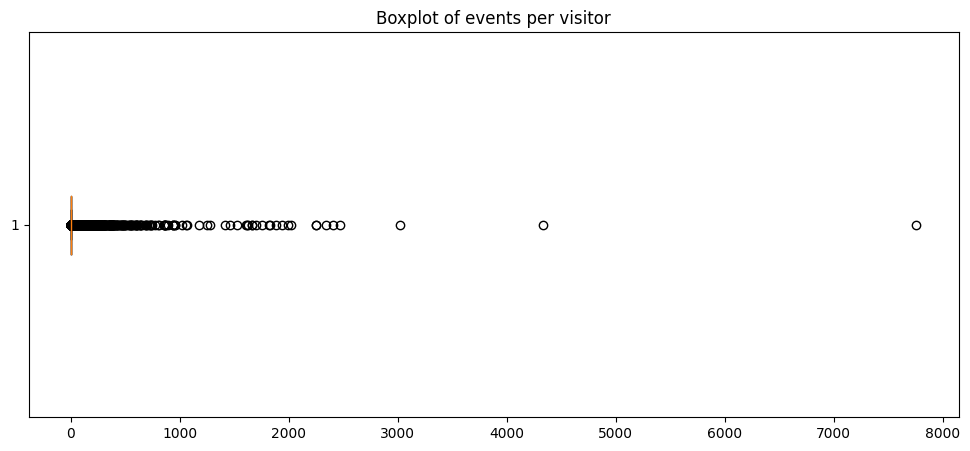

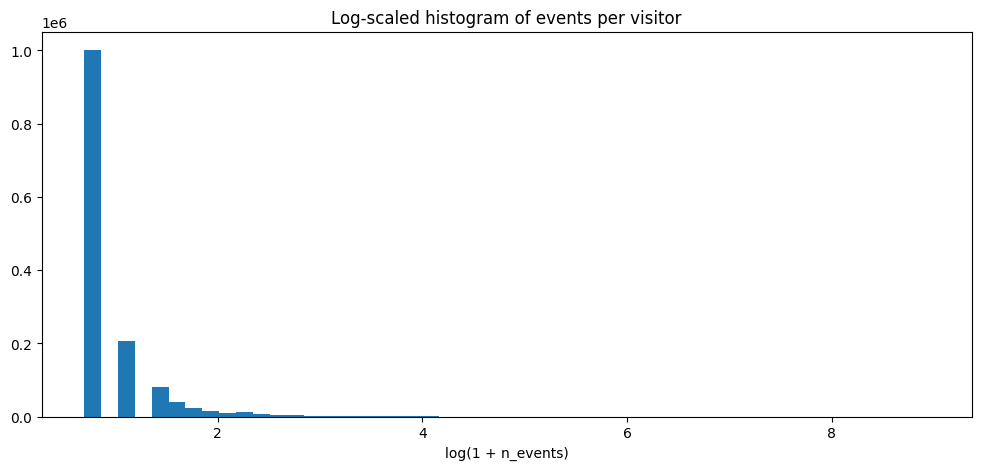

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Visitor outliers
user_counts = events['visitorid'].value_counts().rename('n_events').to_frame().reset_index().rename(columns={'index':'visitorid'})
Q1, Q3 = user_counts['n_events'].quantile([0.25,0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
outlier_users = user_counts[user_counts['n_events'] > upper]
print(f"High-activity visitors (IQR): {len(outlier_users)}")

# Item outliers
item_counts = events['itemid'].value_counts().rename('n_events').to_frame().reset_index().rename(columns={'index':'itemid'})
item_counts['z'] = stats.zscore(item_counts['n_events'])
extreme_items = item_counts[item_counts['z'].abs() > 3]
print(f"Extreme items (z-score >3): {len(extreme_items)}")

# Visualization
plt.figure(figsize=(12,5))
plt.boxplot(user_counts['n_events'], vert=False)
plt.title("Boxplot of events per visitor")
plt.show()

plt.figure(figsize=(12,5))
plt.hist(np.log1p(user_counts['n_events']), bins=50)
plt.title("Log-scaled histogram of events per visitor")
plt.xlabel("log(1 + n_events)")
plt.show()


## 2.2 Preprocess item_properties (both parts), long-form, latest snapshot, pivot selected properties
### 2.2.1 Strategy summary

Item properties are stored as (timestamp, itemid, property, value) and multiple rows exist per (itemid,property) over time. For item-level metadata, we typically want the latest value per (itemid,property).

We will:

- read in chunks,

- keep the latest timestamp per (itemid,property),

- reduce to one row per (itemid,property) then pivot a selected subset of properties (or top-K properties) to wide.

### 2.2.2 Chunked pipeline to create props_latest (pure pandas)


In [27]:
import pandas as pd

# define file paths
parts = ["/kaggle/input/ecommerce-dataset/item_properties_part1.csv",
         "/kaggle/input/ecommerce-dataset/item_properties_part2.csv"]

# read in chunks to avoid memory issues
chunks = []
for file in parts:
    reader = pd.read_csv(file, chunksize=500_000, low_memory=False)
    for chunk in reader:
        chunks.append(chunk)

# combine all chunks into one dataframe
item_props = pd.concat(chunks, ignore_index=True)

# convert timestamp from ms to datetime
item_props['timestamp'] = pd.to_datetime(item_props['timestamp'], unit='ms')

# check initial info
print(item_props.info())
print(item_props.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   itemid     int64         
 2   property   object        
 3   value      object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 618.8+ MB
None
            timestamp  itemid    property                            value
0 2015-06-28 03:00:00  460429  categoryid                             1338
1 2015-09-06 03:00:00  206783         888          1116713 960601 n277.200
2 2015-08-09 03:00:00  395014         400  n552.000 639502 n720.000 424566
3 2015-05-10 03:00:00   59481         790                       n15360.000
4 2015-05-17 03:00:00  156781         917                           828513


### 2.2.3 Handle missing values

In [28]:
# Check missing values per column
missing_counts = item_props.isnull().sum()

print("Missing values per column:")
print(missing_counts)

# Optional: total missing values
total_missing = missing_counts.sum()
print(f"\nTotal missing values in dataset: {total_missing}")


Missing values per column:
timestamp    0
itemid       0
property     0
value        0
dtype: int64

Total missing values in dataset: 0


### 2.2.4 Drop duplicates

In [29]:
item_props = item_props.drop_duplicates(subset=['timestamp','itemid','property','value'])


### 2.2.5 Normalize, standardize, or encode categorical variables.

In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Convert value to numeric safely
# Non-numeric/mixed strings → NaN
item_props['value_numeric'] = pd.to_numeric(item_props['value'], errors='coerce')

# Frequency encode + scale itemid
item_counts = item_props['itemid'].value_counts()
item_props['item_freq'] = item_props['itemid'].map(item_counts)

scaler = RobustScaler()
item_props['item_freq_scaled'] = scaler.fit_transform(item_props[['item_freq']])

# Case 1: Pivoted dataset for EDA, scaling, outlier detection
props_wide = item_props.pivot_table(
    index='itemid',
    columns='property',
    values='value_numeric',
    aggfunc='last'  # latest value per property
).reset_index()

# Scale numeric property columns (fill NaN=0 only for scaling)
num_cols = [c for c in props_wide.columns if c != 'itemid']
props_wide[num_cols] = scaler.fit_transform(props_wide[num_cols].fillna(0))

# Optional: Check pivoted dataset
print("Pivoted dataset sample (props_wide):")
print(props_wide.head())
# Case 2: Long-format clean dataset for sequential modeling
item_props_clean = item_props.drop_duplicates(subset=['timestamp','itemid','property','value'])

# Add temporal features
item_props_clean['week'] = item_props_clean['timestamp'].dt.isocalendar().week
item_props_clean['biweek'] = ((item_props_clean['week'] - 1)//2) + 1
item_props_clean['month'] = item_props_clean['timestamp'].dt.month

# Optional: save long-format clean dataset for future use
# item_props_clean.to_csv("/kaggle/working/item_props_clean.csv", index=False)



Pivoted dataset sample (props_wide):
property  itemid         0    1   10  100  1002  1003  1004  1006  1007  1008  \
0              0       0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1              1  769062.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2              2       0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3              3       0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4              4       0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   

property  1009  101  1010  1011  1012  1013  1014  1015  1017  1019  102  \
0          0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
1          0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
2          0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
3          0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   
4          0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0   

property  1020  102

### 2.2.6 Check for data consistency, outliers, and errors using validation tools part

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1️Check data consistency

# Check for duplicate itemid rows
duplicate_items = props_wide['itemid'].duplicated().sum()
print(f"Duplicate itemid rows in pivoted dataset: {duplicate_items}")

# Summary statistics for numeric properties
num_cols = [c for c in props_wide.columns if c != 'itemid']
print("\nNumeric property summary after scaling:")
print(props_wide[num_cols].describe())

#Outlier detection

# a) IQR method
outlier_counts = {}
for col in num_cols:
    Q1 = props_wide[col].quantile(0.25)
    Q3 = props_wide[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    n_outliers = ((props_wide[col] < lower) | (props_wide[col] > upper)).sum()
    outlier_counts[col] = n_outliers

# Show top 5 properties with most outliers
sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 properties by number of outliers (IQR method):")
for prop, count in sorted_outliers[:5]:
    print(f"{prop}: {count} outliers")

# b) Z-score method (optional)
z_scores = np.abs(stats.zscore(props_wide[num_cols], nan_policy='omit'))
outliers_z = (z_scores > 3).sum(axis=0)
outliers_df = pd.DataFrame({'property': num_cols, 'n_outliers_zscore': outliers_z})
outliers_df = outliers_df.sort_values(by='n_outliers_zscore', ascending=False)
print("\nTop 5 properties by z-score outliers:")
print(outliers_df.head(5))


Duplicate itemid rows in pivoted dataset: 0

Numeric property summary after scaling:
property             0             1            10           100  \
count     4.170530e+05  4.170530e+05  4.170530e+05  4.170530e+05   
mean      1.413380e+04  1.585050e+04  1.229532e+03  3.852533e+02   
std       1.031986e+05  1.354723e+05  3.685934e+04  1.891240e+04   
min       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
max       1.250968e+06  1.200832e+06  1.116693e+06  1.338722e+06   

property          1002           1003          1004           1006  \
count     4.170530e+05  417053.000000  4.170530e+05  417053.000000   
mean      6.005099e+02      36.880780  1.839990e+02     173.339667   
std       2.571462e+04    5325.628071  1.194948e+04   11544.662128   
min       0.000000e+00

/tmp/ipykernel_36/1529006020.py:37: RuntimeWarning: invalid value encountered in greater
  outliers_z = (z_scores > 3).sum(axis=0)



Top 5 properties by z-score outliers:
    property  n_outliers_zscore
518      550              38589
492      521              35806
886      935              25651
785      830              24514
743      785              24163


- Outlier counts are high because props_wide has ~235k items, so even “rare” values show up as tens of thousands.

- Some outliers may be legitimate values (e.g., high-priced items)

| Property  | # Outliers | Possible Meaning                                    |
| --------- | ---------- | --------------------------------------------------- |
| 1036      | 94,248     | Very skewed or highly variable numeric property     |
| 713       | 74,910     | May contain rare extreme values                     |
| 348       | 61,693     | Could indicate measurement or encoding issues       |
| available | 59,015     | Likely stock/availability info, many zeros/extremes |
| 46        | 54,141     | Possibly a low-range property with spikes           |


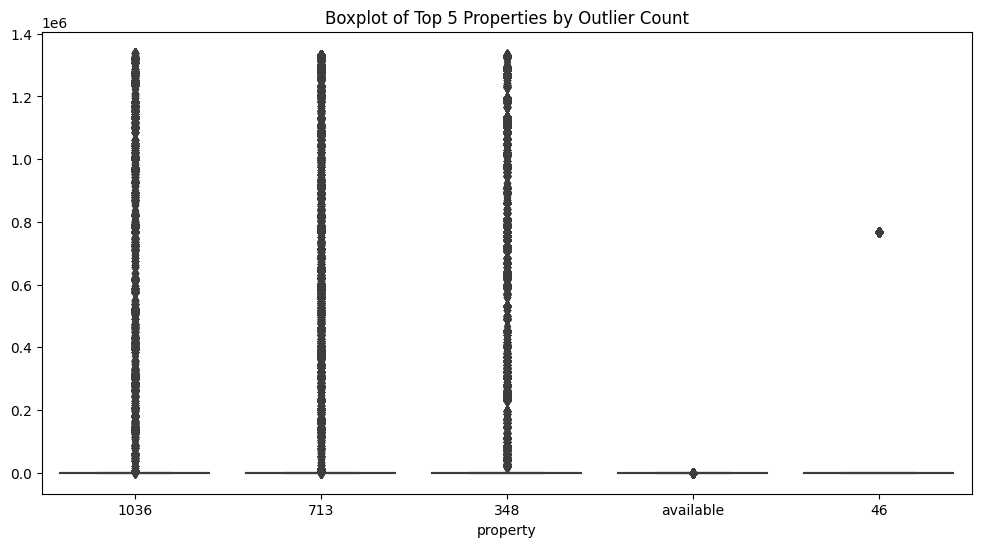

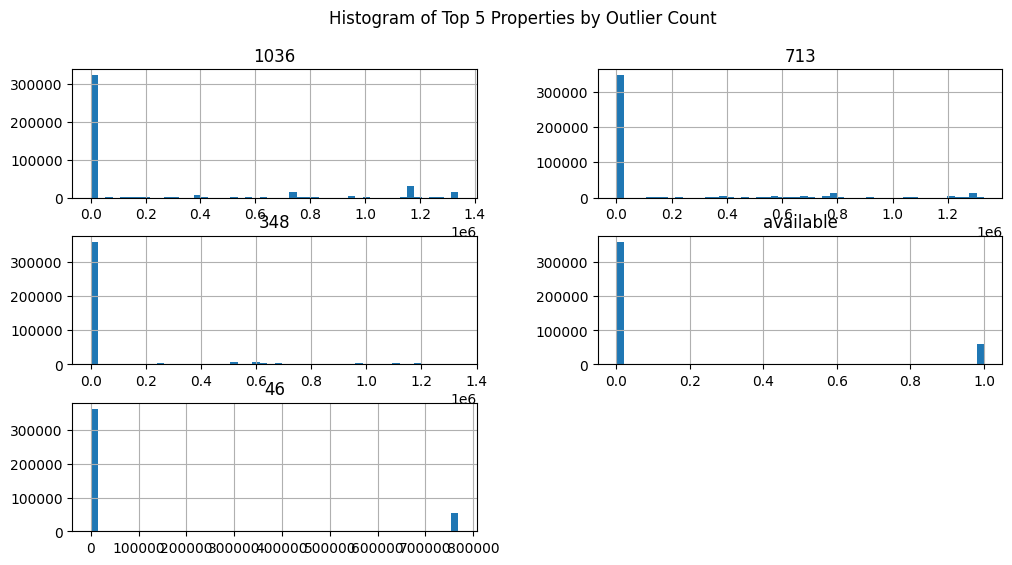

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 5 properties with most outliers
top_props = ['1036', '713', '348', 'available', '46']

plt.figure(figsize=(12,6))
sns.boxplot(data=props_wide[top_props])
plt.title("Boxplot of Top 5 Properties by Outlier Count")
plt.show()

# Optional: histograms for distribution
props_wide[top_props].hist(bins=50, figsize=(12,6))
plt.suptitle("Histogram of Top 5 Properties by Outlier Count")
plt.show()


### 2.2.7 Present samples from preprocessed datasets.

In [36]:
# Check long-format dataset
print("\nLong-format clean dataset sample (item_props_clean):")
print(item_props_clean[['itemid','property','value_numeric','item_freq_scaled','week','biweek','month']].head())



Long-format clean dataset sample (item_props_clean):
   itemid    property  value_numeric  item_freq_scaled  week  biweek  month
0  460429  categoryid         1338.0          0.341463    26      13      6
1  206783         888            NaN          0.585366    36      18      9
2  395014         400            NaN          0.097561    32      16      8
3   59481         790            NaN          0.609756    19      10      5
4  156781         917       828513.0         -0.463415    20      10      5


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


## 2.3 Preprocess category_tree


In [40]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Check missing values
print("Missing values per column:")
print(category_tree.isnull().sum())
# If any missing, fill parentid with 0 (root category) or drop
category_tree['parentid'] = category_tree['parentid'].fillna(0).astype(int)

# Remove duplicates
category_tree = category_tree.drop_duplicates(subset=['categoryid', 'parentid'])

# Encode categorical variables
# categoryid and parentid are integers; can label encode if needed for modeling
le_category = LabelEncoder()
le_parent = LabelEncoder()

category_tree['categoryid_encoded'] = le_category.fit_transform(category_tree['categoryid'])
category_tree['parentid_encoded'] = le_parent.fit_transform(category_tree['parentid'])

# Check data consistency
# a. Check for cycles in hierarchy (category = parent)
cycles = (category_tree['categoryid'] == category_tree['parentid']).sum()
print(f"Number of categories that are their own parent: {cycles}")

# b. Check for unique categoryid
unique_categories = category_tree['categoryid'].nunique()
total_rows = len(category_tree)
print(f"Total rows: {total_rows}, Unique categoryid: {unique_categories}")

# c. Check parentid references exist in categoryid (except 0/root)
valid_categories = pd.concat([category_tree['categoryid'], pd.Series([0])])
invalid_parents = category_tree.loc[~category_tree['parentid'].isin(valid_categories)]
print(f"Rows with invalid parentid references: {len(invalid_parents)}")# Present sample
# -------------------------
print("\nSample preprocessed category_tree:")
print(category_tree.head())


Missing values per column:
categoryid            0
parentid              0
categoryid_encoded    0
parentid_encoded      0
dtype: int64
Number of categories that are their own parent: 0
Total rows: 1669, Unique categoryid: 1669
Rows with invalid parentid references: 0

Sample preprocessed category_tree:
   categoryid  parentid  categoryid_encoded  parentid_encoded
0        1016       213                 998                52
1         809       169                 795                40
2         570         9                 557                 2
3        1691       885                1661               188
4         536      1691                 525               359


## 3. Data Quality Assessment
### 3.1 Events Dataset

Events value counts:
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


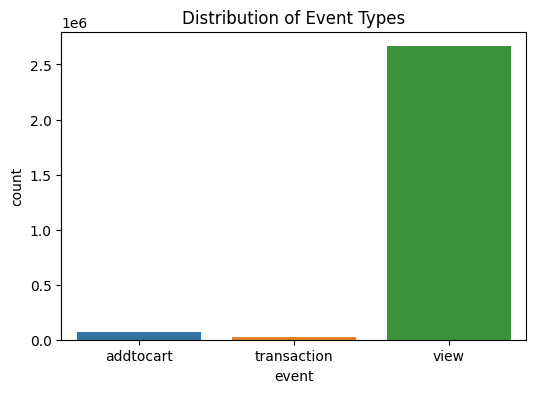

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


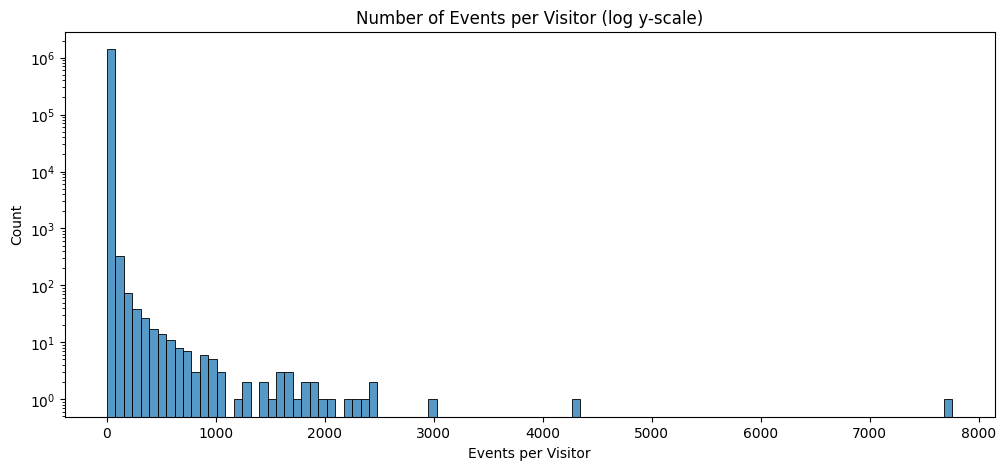

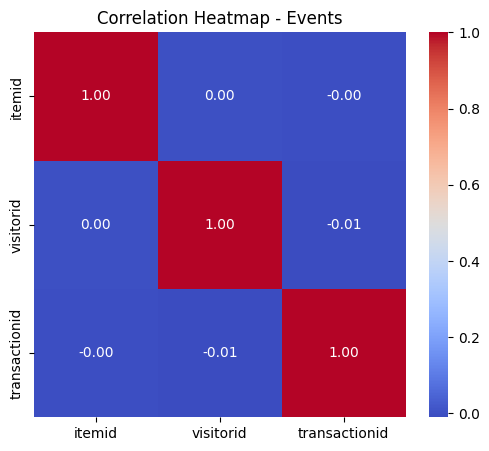

Event type proportions:
event
view           0.966823
addtocart      0.025027
transaction    0.008149
Name: proportion, dtype: float64


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# a) Distribution of key features
# -------------------------
print("Events value counts:")
print(events['event'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='event', data=events)
plt.title("Distribution of Event Types")
plt.show()

# Events per visitor distribution
visitor_counts = events['visitorid'].value_counts()
plt.figure(figsize=(12,5))
sns.histplot(visitor_counts, bins=100, log_scale=(False, True))
plt.title("Number of Events per Visitor (log y-scale)")
plt.xlabel("Events per Visitor")
plt.ylabel("Count")
plt.show()

# -------------------------
# b) Correlations
# -------------------------
# Only numeric features: itemid, visitorid, transactionid (if any)
numeric_cols = ['itemid', 'visitorid', 'transactionid']
plt.figure(figsize=(6,5))
sns.heatmap(events[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Events")
plt.show()

# -------------------------
# c) Imbalanced class check
# -------------------------
print("Event type proportions:")
print(events['event'].value_counts(normalize=True))


**Insights for events:**

- event type is highly imbalanced (e.g., view dominates addtocart or transaction)

- Some visitors have extremely high activity → outliers

- Correlation among numeric IDs is low (mostly identifiers, not meaningful numerics)

### 3.2 Item Properties (pivoted props_wide)

<Figure size 1200x600 with 0 Axes>

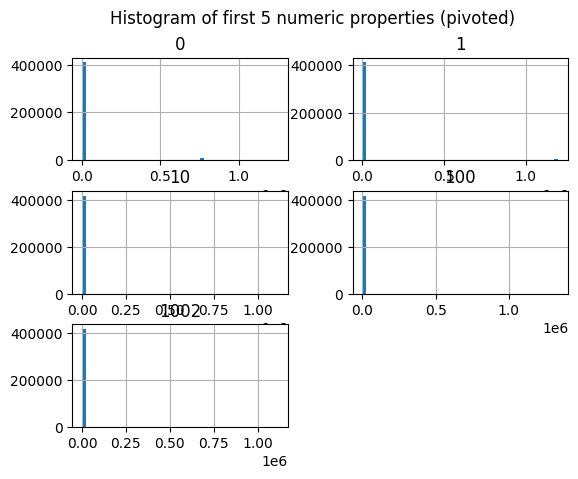

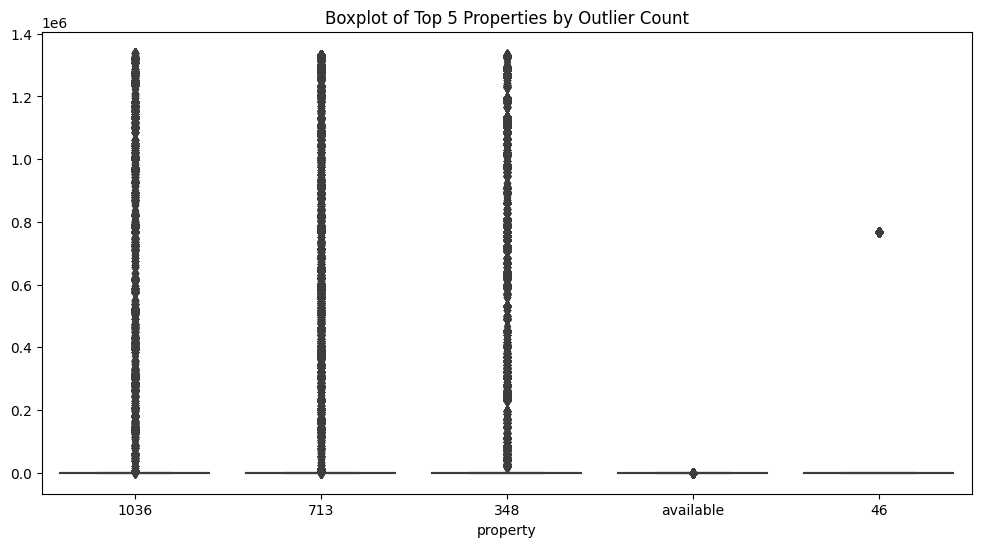

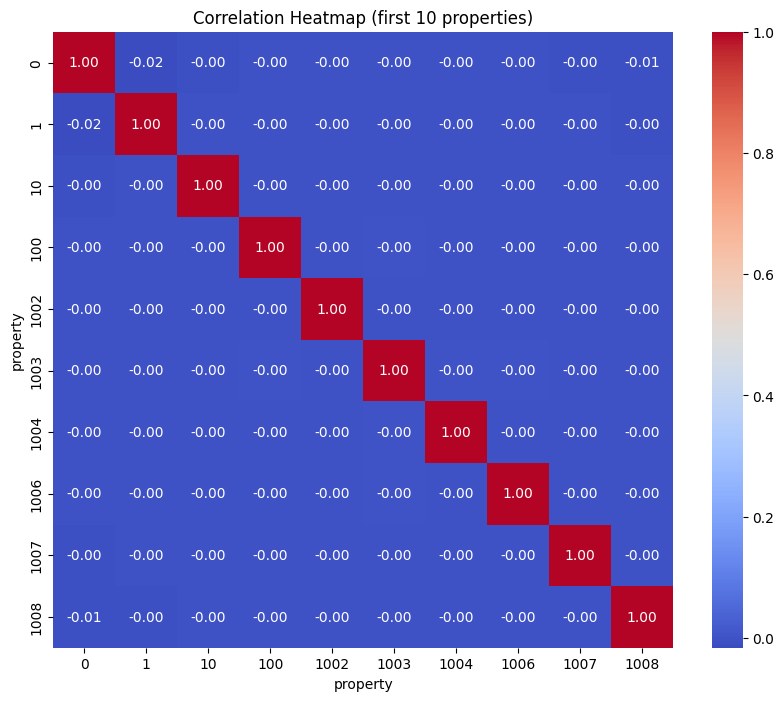

In [42]:
# -------------------------
# a) Distribution of numeric properties
# -------------------------
num_cols = [c for c in props_wide.columns if c != 'itemid']

plt.figure(figsize=(12,6))
props_wide[num_cols[:5]].hist(bins=50)
plt.suptitle("Histogram of first 5 numeric properties (pivoted)")
plt.show()

# -------------------------
# b) Boxplots for top 5 properties with most outliers
# -------------------------
top_props = ['1036', '713', '348', 'available', '46']  # from previous outlier check

plt.figure(figsize=(12,6))
sns.boxplot(data=props_wide[top_props])
plt.title("Boxplot of Top 5 Properties by Outlier Count")
plt.show()

# -------------------------
# c) Correlation heatmap
# -------------------------
plt.figure(figsize=(10,8))
sns.heatmap(props_wide[num_cols[:10]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (first 10 properties)")
plt.show()


**Insights for item_props:**

- Many properties are highly skewed → presence of extreme values

- Some properties are correlated → could indicate related attributes (e.g., dimensions, price)

- Outliers may need consideration depending on modeling goal

### 3.3 Category Tree

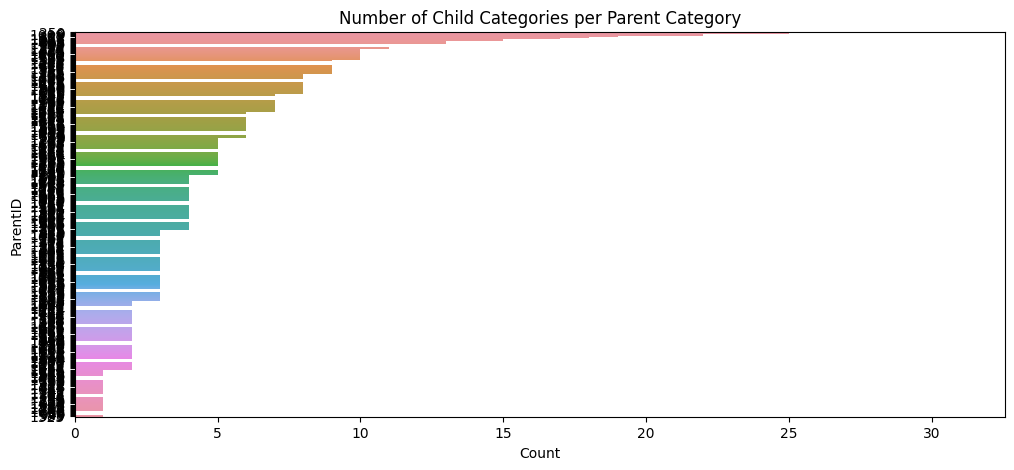

Number of top-level categories: 25
      categoryid  parentid  categoryid_encoded  parentid_encoded
5            231         0                 227                 0
589          791         0                 777                 0
861         1490         0                1465                 0
939          431         0                 421                 0
1111         755         0                 741                 0


In [43]:
# Distribution of parent categories
plt.figure(figsize=(12,5))
sns.countplot(y='parentid', data=category_tree, order=category_tree['parentid'].value_counts().index)
plt.title("Number of Child Categories per Parent Category")
plt.xlabel("Count")
plt.ylabel("ParentID")
plt.show()

# Top-level categories (parentid=0)
top_level = category_tree[category_tree['parentid']==0]
print(f"Number of top-level categories: {len(top_level)}")
print(top_level.head())


**Insights for category_tree:**

- Most categories are leaf nodes → some parents have many children

- No missing or invalid parent references

- Hierarchy can be used for grouping or recommendation rules

### 3.4 Cross-dataset checks
What this cross-dataset check shows:

- Event-Item Coverage

How many items actually have events recorded.

Detects items with zero interactions (cold start).

- Visitor Activity

Identifies extremely active visitors (outliers) or inactive ones.

- Property Coverage per Item

Detects items with very few or no properties, which could impact modeling.

- Category Coverage

Counts how many items belong to each parent category.

Highlights category imbalance, important for recommendations.

Total items in item_props: 417053
Items with events: 235061
Items without events: 181992


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


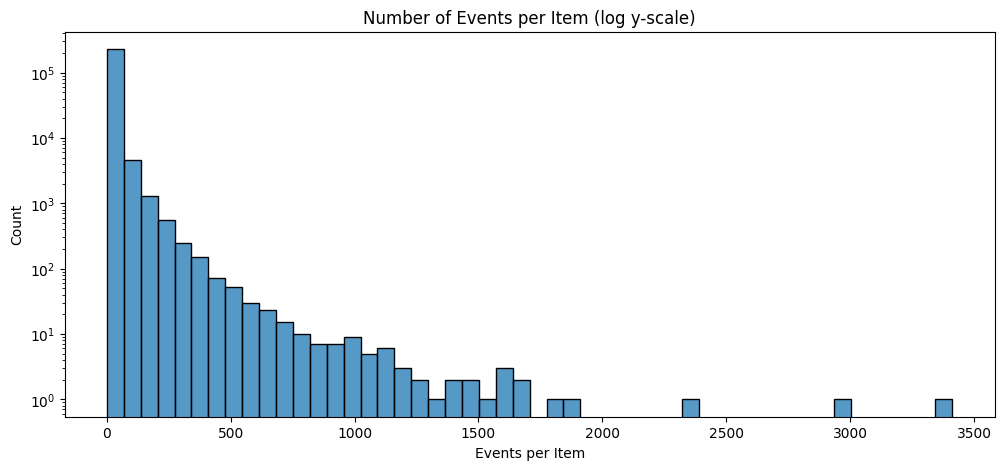

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


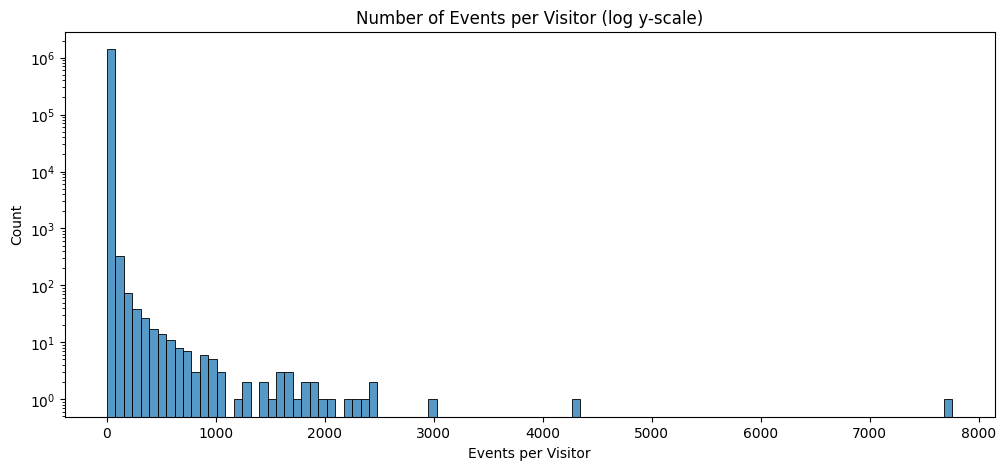

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


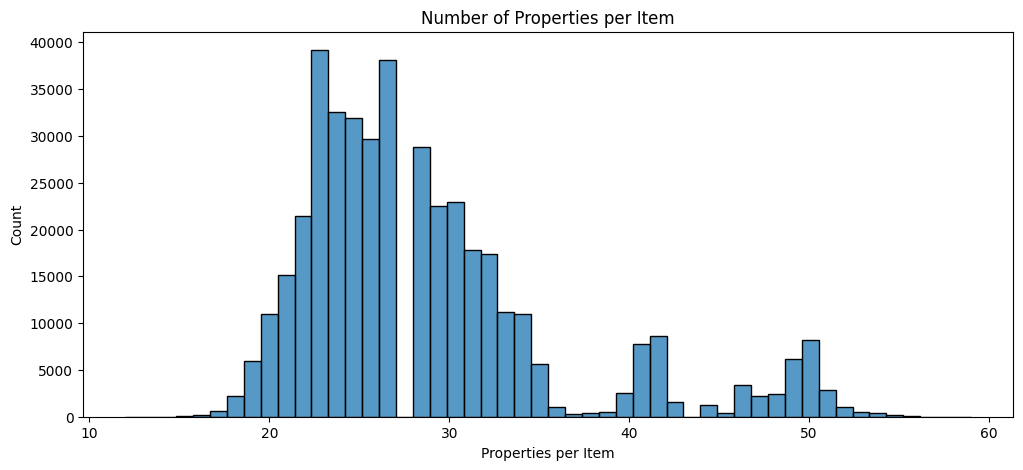

Items with fewer than 3 properties: 0


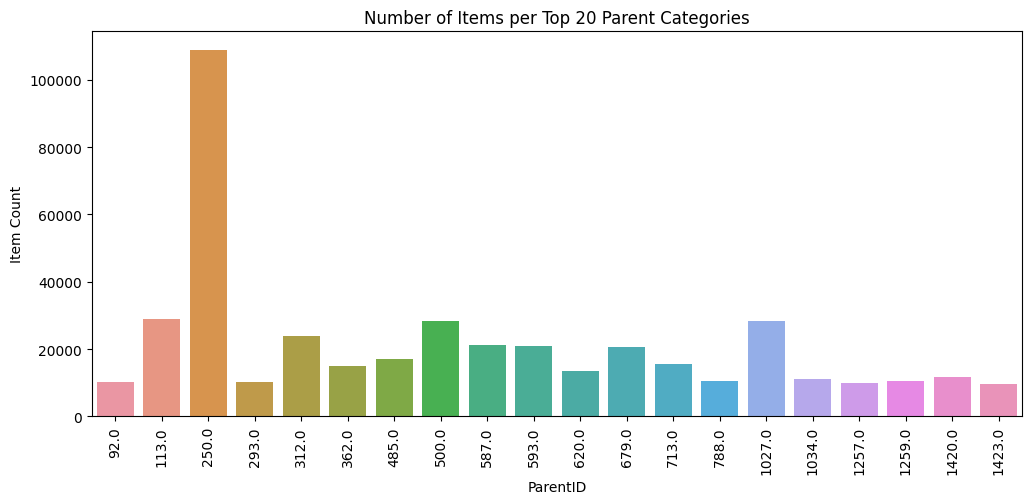

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Event-Item Coverage
# How many items have events
items_with_events = events['itemid'].nunique()
total_items = item_props['itemid'].nunique()
print(f"Total items in item_props: {total_items}")
print(f"Items with events: {items_with_events}")
print(f"Items without events: {total_items - items_with_events}")

# Histogram: number of events per item
item_event_counts = events['itemid'].value_counts()
plt.figure(figsize=(12,5))
sns.histplot(item_event_counts, bins=50, log_scale=(False, True))
plt.title("Number of Events per Item (log y-scale)")
plt.xlabel("Events per Item")
plt.ylabel("Count")
plt.show()

# Visitor Activity Distribution
visitor_counts = events['visitorid'].value_counts()
plt.figure(figsize=(12,5))
sns.histplot(visitor_counts, bins=100, log_scale=(False, True))
plt.title("Number of Events per Visitor (log y-scale)")
plt.xlabel("Events per Visitor")
plt.ylabel("Count")
plt.show()

# Property Coverage per Item
# Count of properties available for each item
prop_counts = item_props.groupby('itemid')['property'].nunique()
plt.figure(figsize=(12,5))
sns.histplot(prop_counts, bins=50)
plt.title("Number of Properties per Item")
plt.xlabel("Properties per Item")
plt.ylabel("Count")
plt.show()

# Check for items with very few or zero properties
few_props_items = prop_counts[prop_counts < 3]
print(f"Items with fewer than 3 properties: {len(few_props_items)}")

# Category Coverage
# Items per top-level category
# Merge item_props with category info
item_category = item_props[item_props['property'] == 'categoryid'][['itemid','value_numeric']]
item_category = item_category.rename(columns={'value_numeric':'categoryid'})
item_category = item_category.merge(category_tree, on='categoryid', how='left')

items_per_parent = item_category['parentid'].value_counts()
plt.figure(figsize=(12,5))
sns.barplot(x=items_per_parent.index[:20], y=items_per_parent.values[:20])
plt.xticks(rotation=90)
plt.title("Number of Items per Top 20 Parent Categories")
plt.xlabel("ParentID")
plt.ylabel("Item Count")
plt.show()


There outputs tell us an important cross-dataset insight:

- Out of 417,053 items in item_props, only 235,061 items (~56%) have any recorded events.

- That means 181,992 items (~44%) have no events at all.


**Cold-start items:**

These items may never appear in purchase or recommendation history.

For modeling, we might need content-based features (from item_props) rather than collaborative signals.

**Data sparsity:**

Event interactions are not uniformly distributed across all items.

When building recommendation models, consider weighting items or handling missing interactions carefully.

**EDA & reporting:**

Below is a report to highlight the fraction of items with vs. without events.

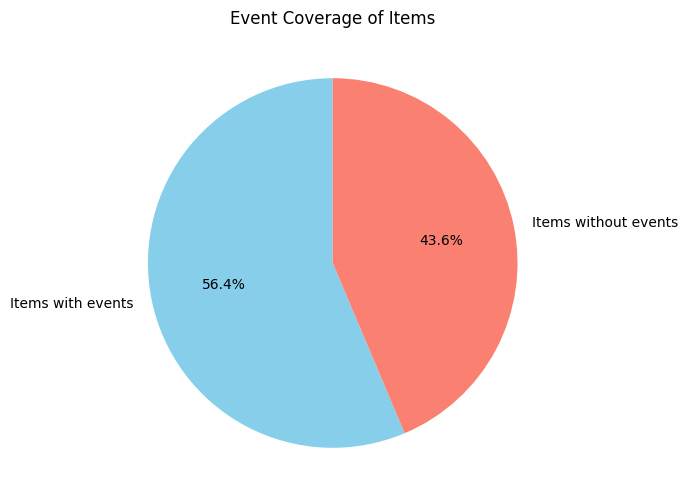

In [45]:
plt.figure(figsize=(6,6))
plt.pie([items_with_events, total_items - items_with_events],
        labels=['Items with events', 'Items without events'],
        autopct='%1.1f%%', startangle=90, colors=['skyblue','salmon'])
plt.title("Event Coverage of Items")
plt.show()
